In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import GridSearchCV

sns.set(style='whitegrid', context='notebook')

# EDA для набора данных Wine  
Данный ноутбук выполняет расширенный Exploratory Data Analysis (EDA) для датасета `wine` из sklearn.

Включено:
- обзор данных  
- визуализация распределений  
- сравнение классов  
- корреляции  
- PCA  
- t-SNE  
- кластеризация  
- анализ выбросов  
- важность признаков  
- преобразования  
- рекомендации  


Датасет:

178 наблюдений

15 признаков, из них:

– 13 числовых признаков состава вина

– 1 числовой таргет

– 1 категориальный признак (class)

Загрузим датасет `wine` из `sklearn`.

In [24]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['class'] = df['target'].map({0:'Класс 0',1:'Класс 1',2:'Класс 2'})

Проверим корректность загрузки данных посмотрев первые 7 строк датасета.

In [26]:
df.head(7)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Класс 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Класс 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Класс 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Класс 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Класс 0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,Класс 0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,Класс 0


Размер датасета:

In [28]:
print("Размер:", df.shape)

Размер: (178, 15)


Информация о данных в датасете:

In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Пропущенные значения в датасете:

In [30]:
print(df.isna().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
class                           0
dtype: int64


In [52]:
columns = df.columns.tolist()
print("Все признаки в датасете:")
for col in columns:
    print(col)

Все признаки в датасете:
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline
target
class
is_outlier
cluster


**Вывод:** в датасете нет пропущенных значений.

Посмотрим на основные статистики нашего датасета:

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Выводы:

- в датасете нет нулевых и отрицательных значений, они могли бы классифицироваться как пропуски.
- в целом значения `min` и `max` выглядят адекватно для каждого признака.
-  признаки имеют разный масштаб, следовательно перед PCA нужно из стандартизировать.
-  признаки с большим разрывом между `median` и `max` выглядят как скошенные вправо (`malic_acid`, `flavanoids`, `color_intensity`, `proline`) можно провести лог-трансформацию, но перед этим стоит посмотреть, как эти признаки выглядят на гистограмме.
-  `malic_acid`, `color_intensity`, `proline` - вариативные признаки (сравнение `std` и `mean`) - высоковариативные признаки обычно лучше разделяют классы.
-  целевой признак (`target`) равномерно покрывает 3 класса: `mean=0.938`, `std=0.775` - балансировка не требуется.


Построим гистограммы и посмотрим на распределение:

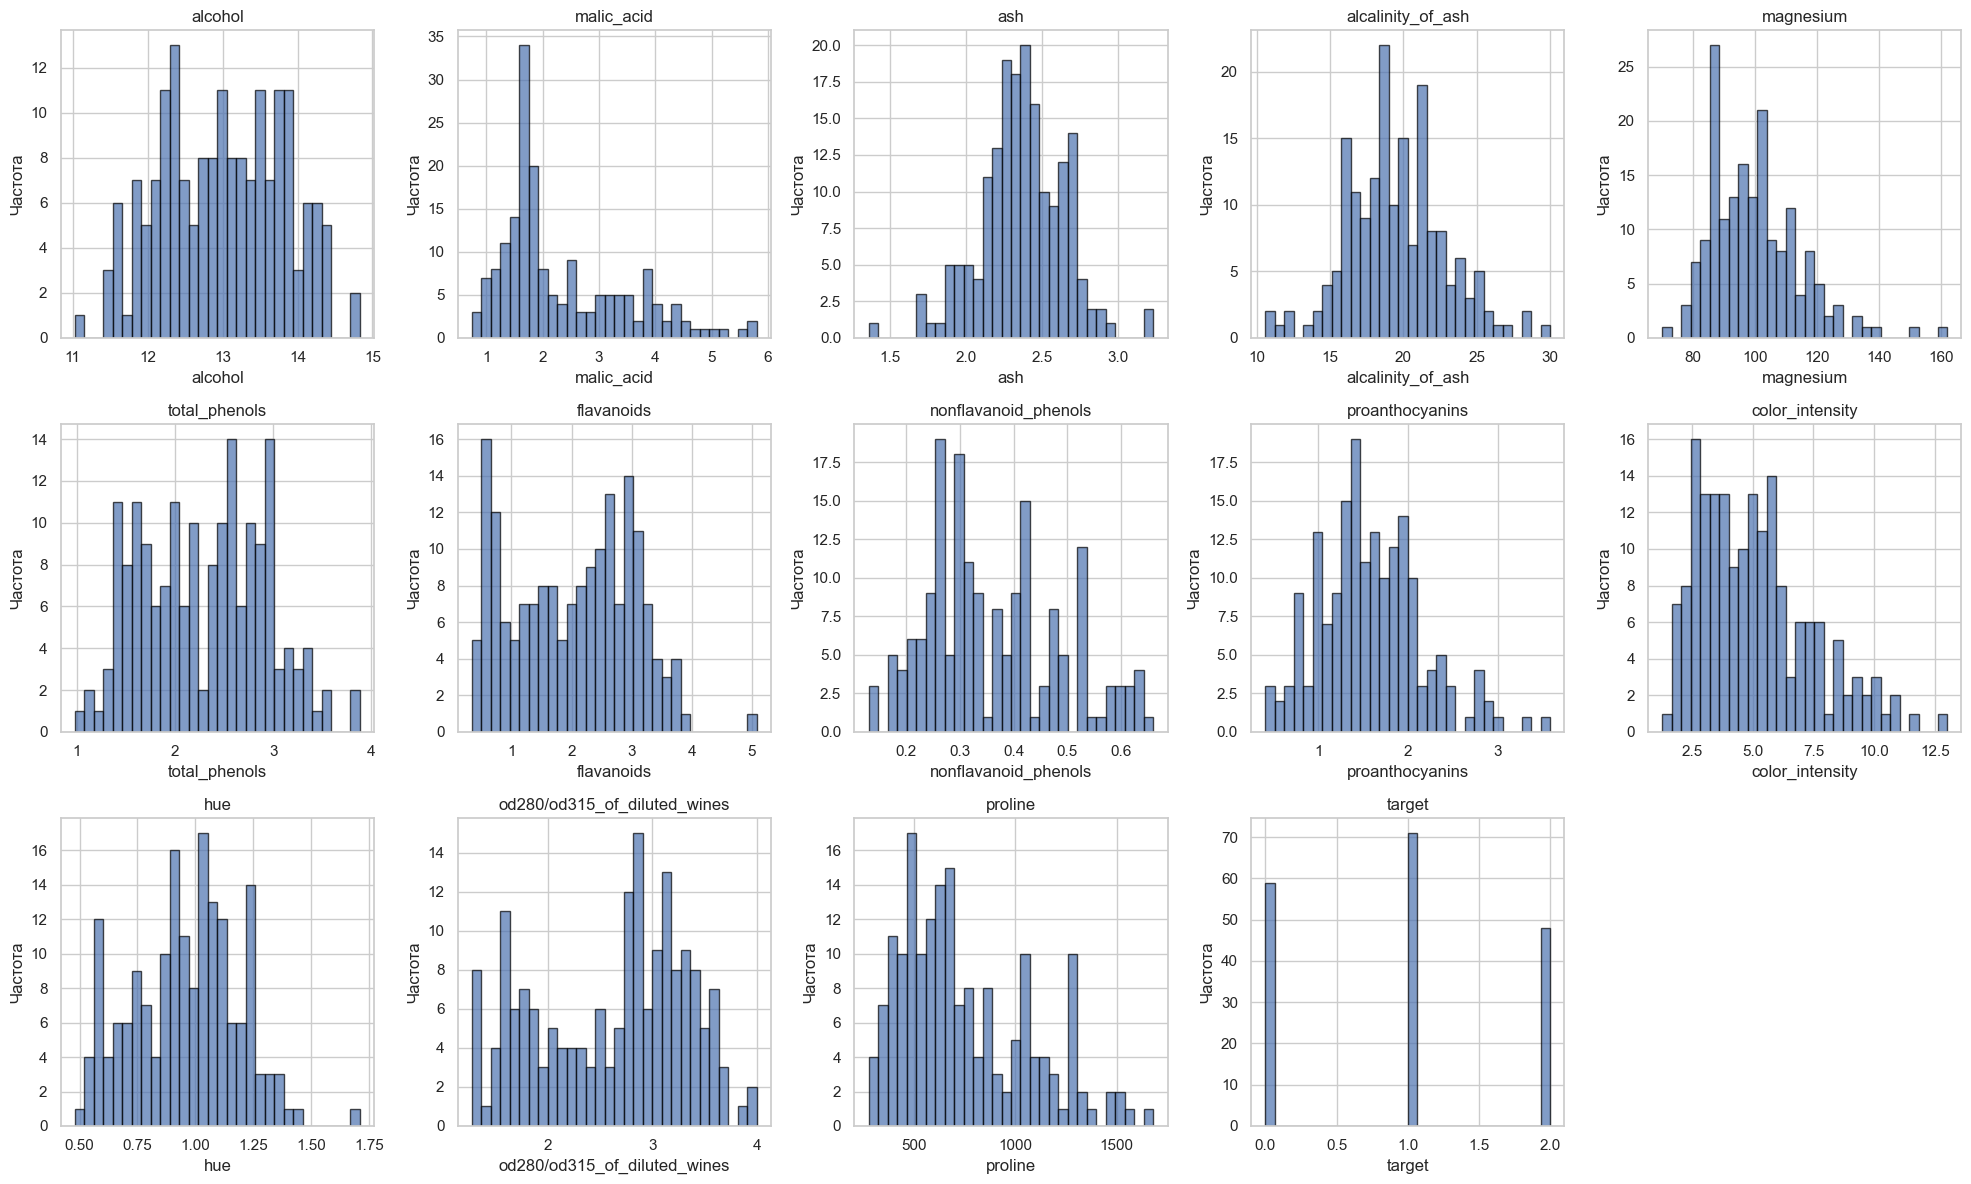

In [32]:
columns = df_wine.columns.to_list()
columns.pop()
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(df_wine[col], bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

for i in range(len(columns), 15):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Выводы:
- `malic_acid`, `magnesium`, `color_intensity` имеют лог-нормальное распределение. Возможно имеет смысл провести лог-трансформацию этих данных.
- классы сбалансированы.
- в данных нет выбросов.

Вообще с утверждением о том, что в данных нет выбросов можно поспорить, однако все значения укладываются в физический смысл своего признака.

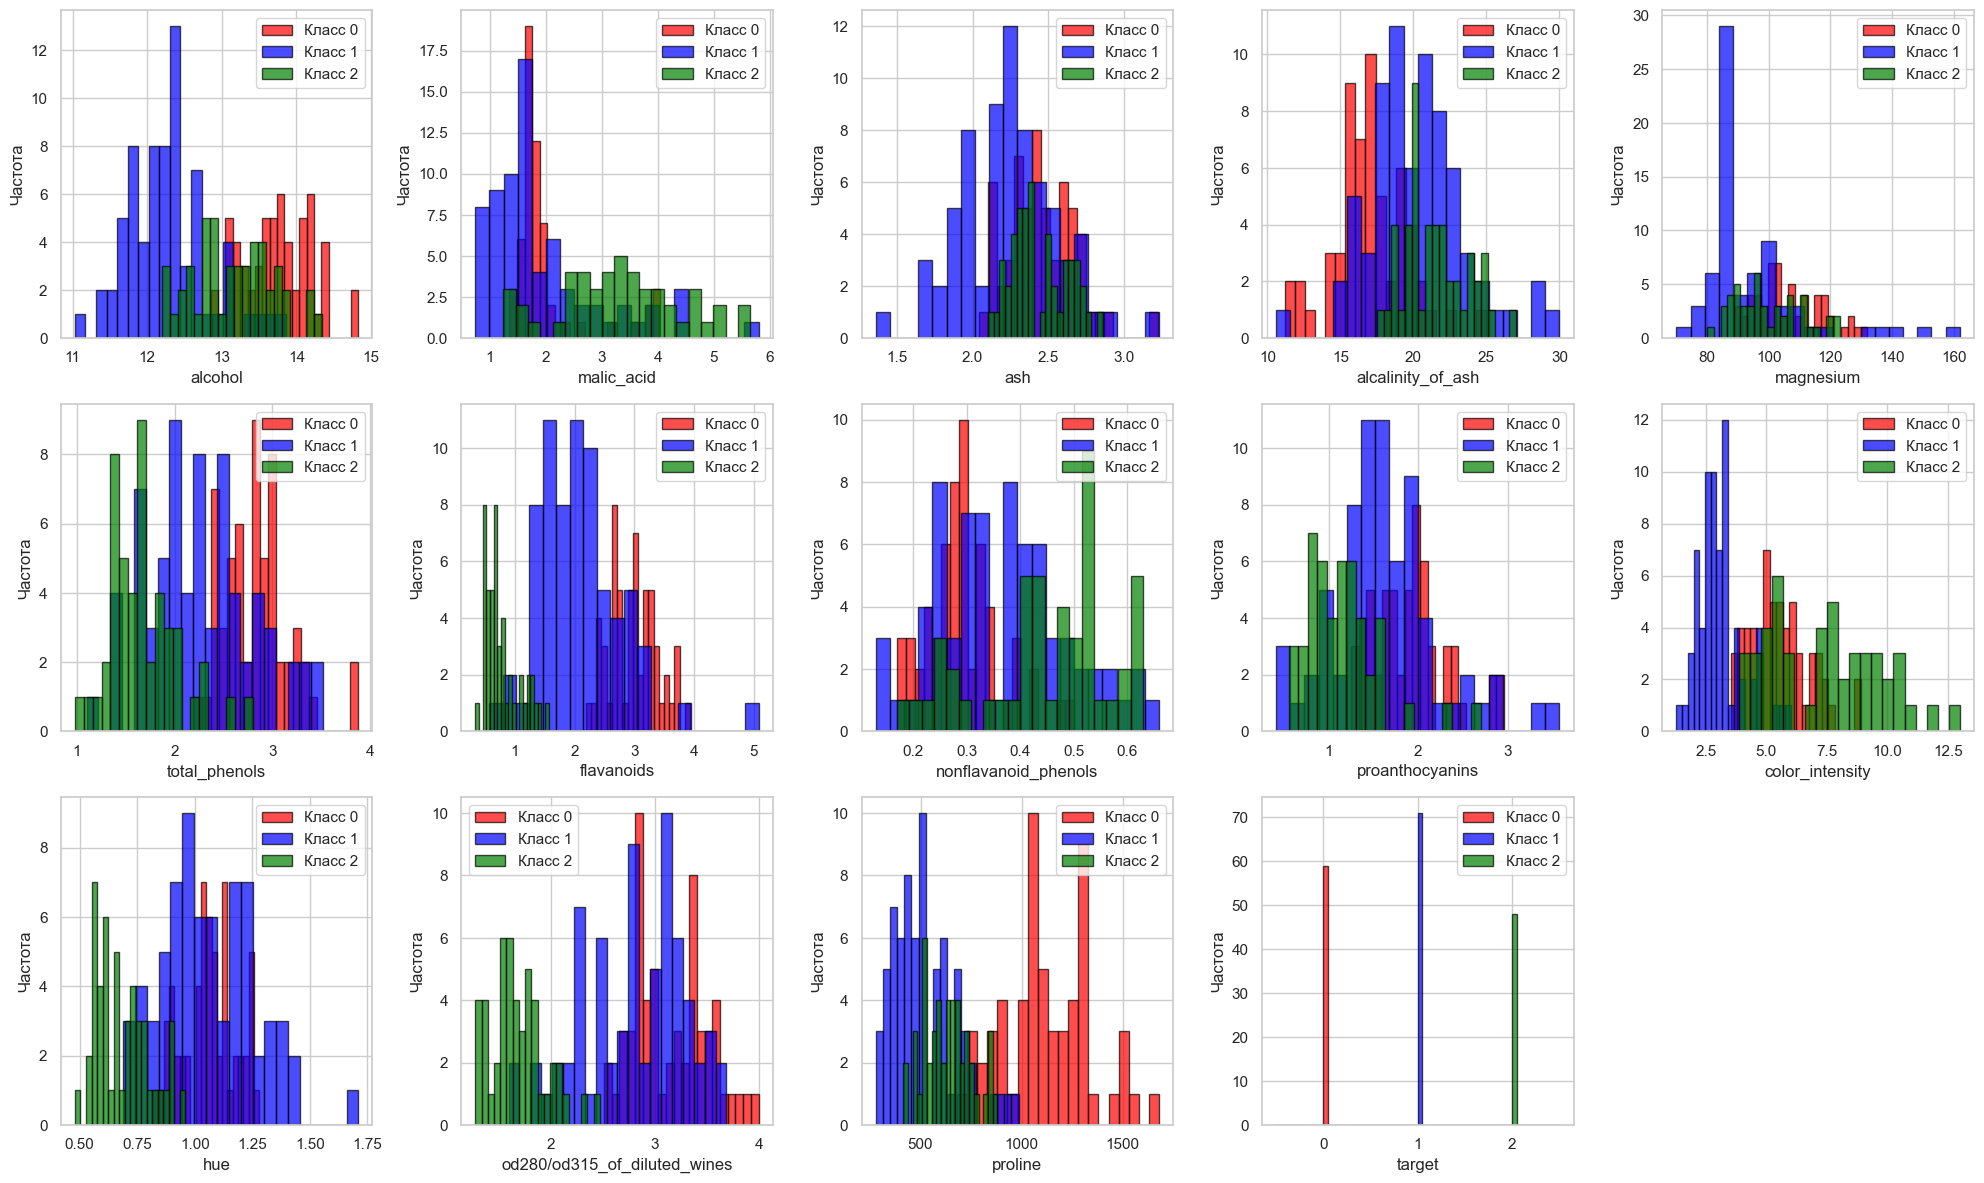

In [34]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

classes = df_wine['class'].unique()
colors = ['red', 'blue', 'green']
for i, col in enumerate(columns):
    for class_val, color in zip(classes, colors):
        class_data = df_wine[df_wine['class'] == class_val][col]
        axes[i].hist(class_data, bins=20, alpha=0.7, edgecolor='black', 
                    color=color, label=f'{class_val}')
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].legend()

for i in range(len(columns), 15):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

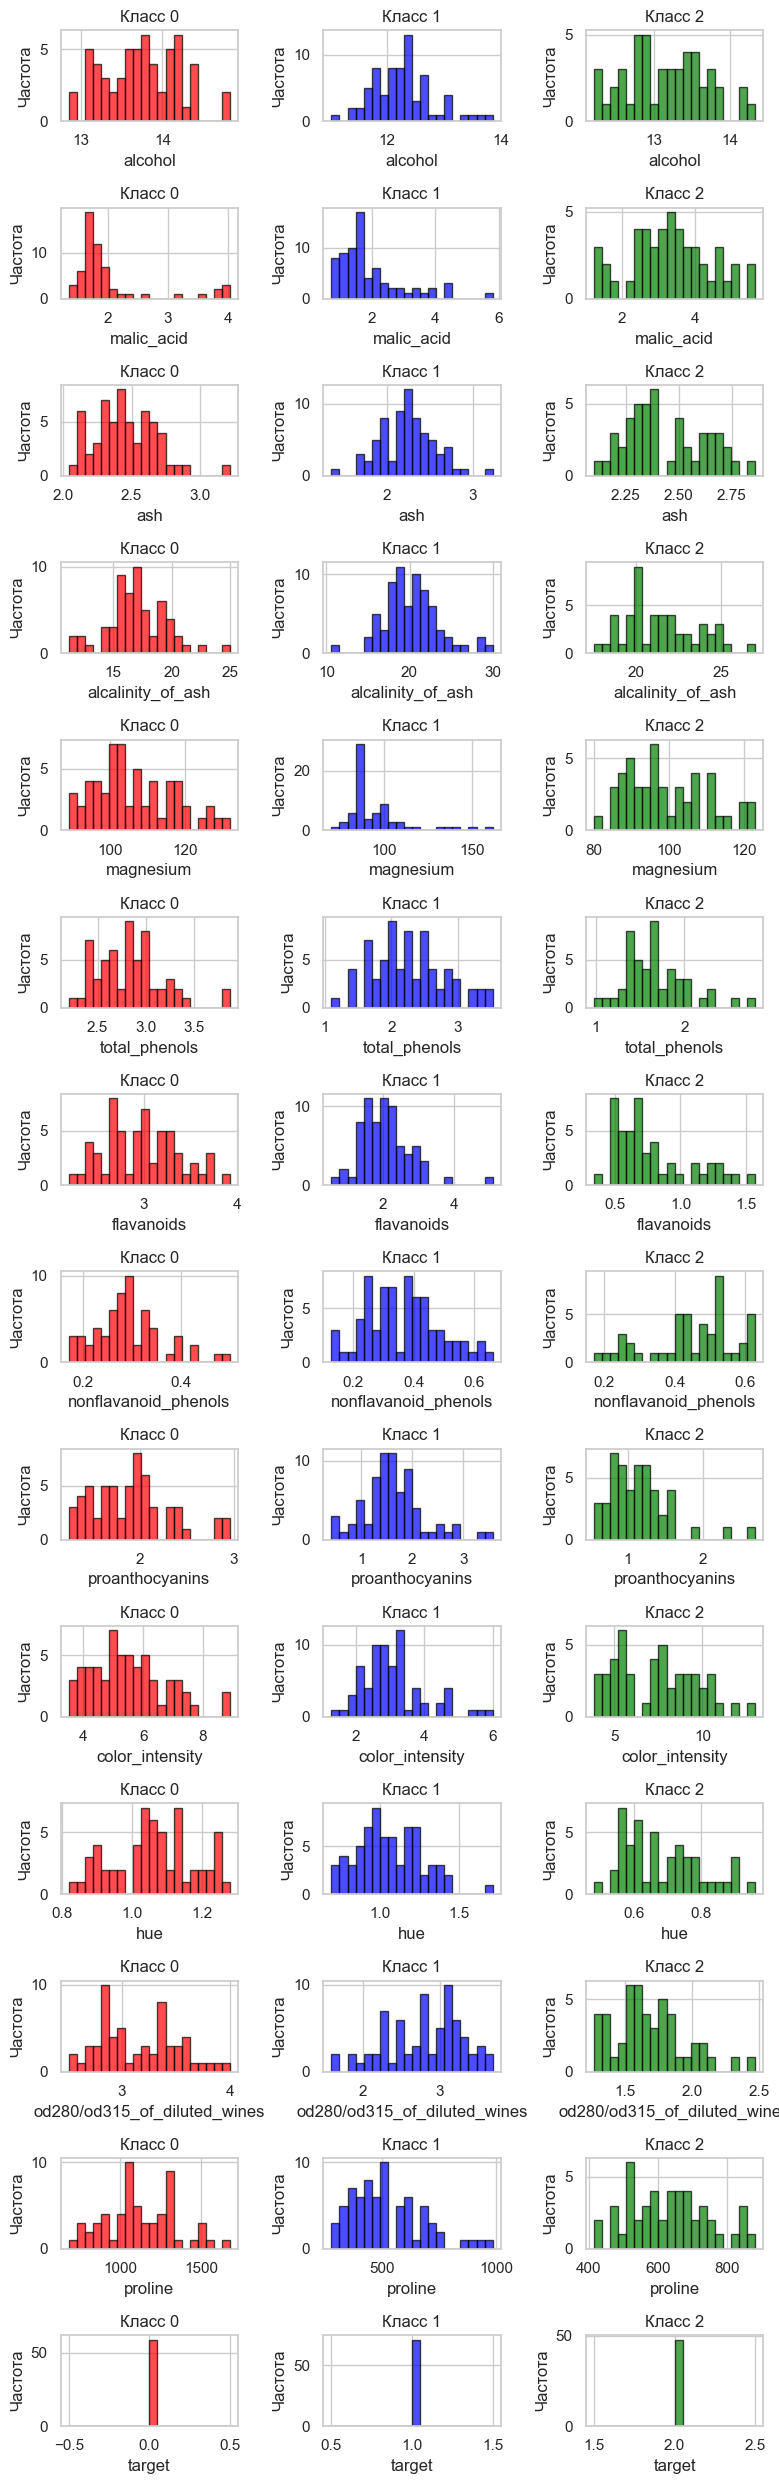

In [35]:
fig, axes = plt.subplots(len(columns), 3, figsize=(8, 25))

for i, class_val in enumerate(classes):
    for j, col in enumerate(columns):
        class_data = df_wine[df_wine['class'] == class_val][col]
        axes[j, i].hist(class_data, bins=20, alpha=0.7, edgecolor='black', 
                       color=colors[i])
        axes[j, i].set_title(f'{class_val}')
        axes[j, i].set_xlabel(col)
        axes[j, i].set_ylabel('Частота')        

plt.tight_layout()
plt.show()

Также были построены гистограммы для отдельных классов.

Построим box-plot для каждого класса.

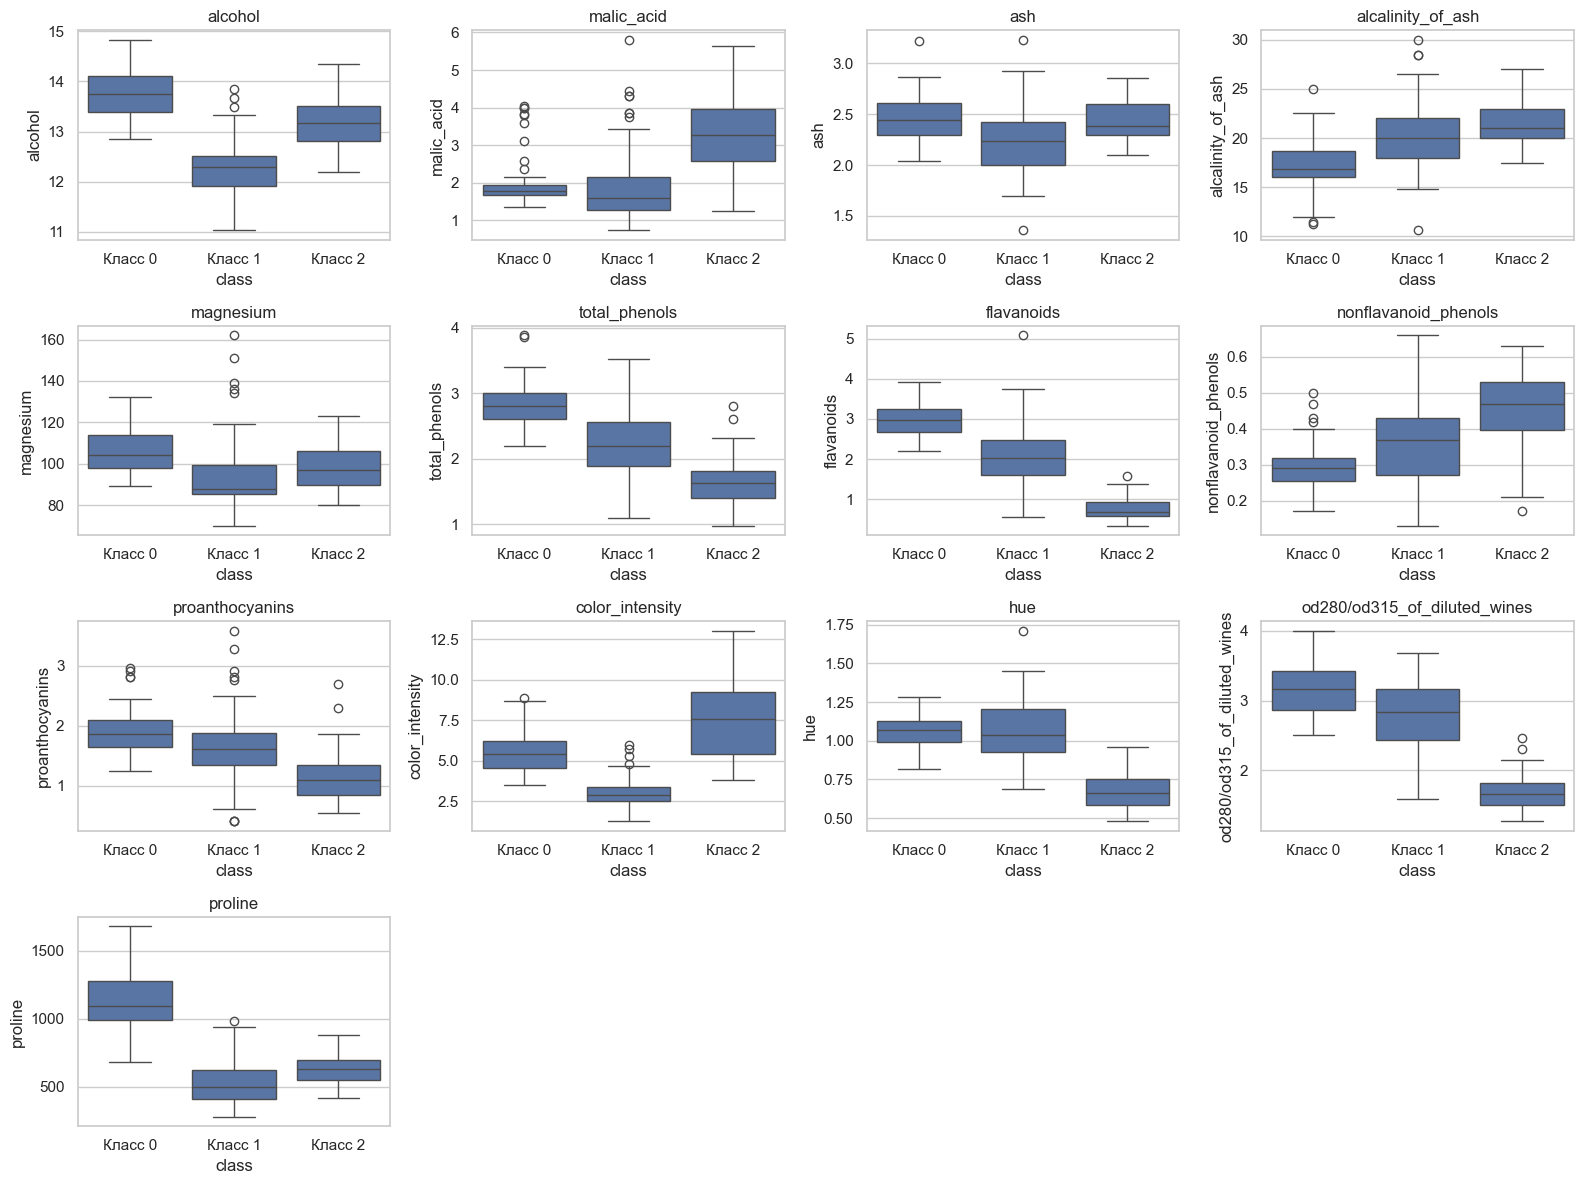

In [36]:
plt.figure(figsize=(16,12))
for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(x='class', y=col, data=df)
    plt.title(col)
plt.tight_layout()


**Local Outlier Factor (LOF)**
Для анализа аномалий в данных можно использовать метод Local Outlier Factor (LOF). LOF — это алгоритм для обнаружения выбросов, который оценивает локальную плотность каждой точки относительно её соседей.

**Принцип работы:**

- Для каждой точки определяется её локальная плотность на основе выбранного числа ближайших соседей (n_neighbors).
- Вычисляется отношение плотности точки к плотностям соседей.
- Если плотность точки значительно меньше плотностей соседей, она помечается как выброс (outlier).

**Особенности:**
- LOF хорошо работает для выявления выбросов в данных с неоднородной плотностью.
- Результатом работы алгоритма является массив меток:
-1 — точка является выбросом
1 — нормальная точка

In [78]:
lof = LocalOutlierFactor(n_neighbors=20)
outlier_flags = lof.fit_predict(X_s)
df['is_outlier'] = outlier_flags == -1

print("Найденные пропуски:", df['is_outlier'].sum())
df[df['is_outlier']].head()


Найденные пропуски: 6


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class,is_outlier,cluster
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1,Класс 1,True,0
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,1,Класс 1,True,0
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,1,Класс 1,True,2
95,12.47,1.52,2.20,19.0,162.0,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937.0,1,Класс 1,True,2
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1,Класс 1,True,2


Мною было принято решение не удалять выбросы, т.к. в датасете достаточно мало данных и я не вижу аномальных значений.

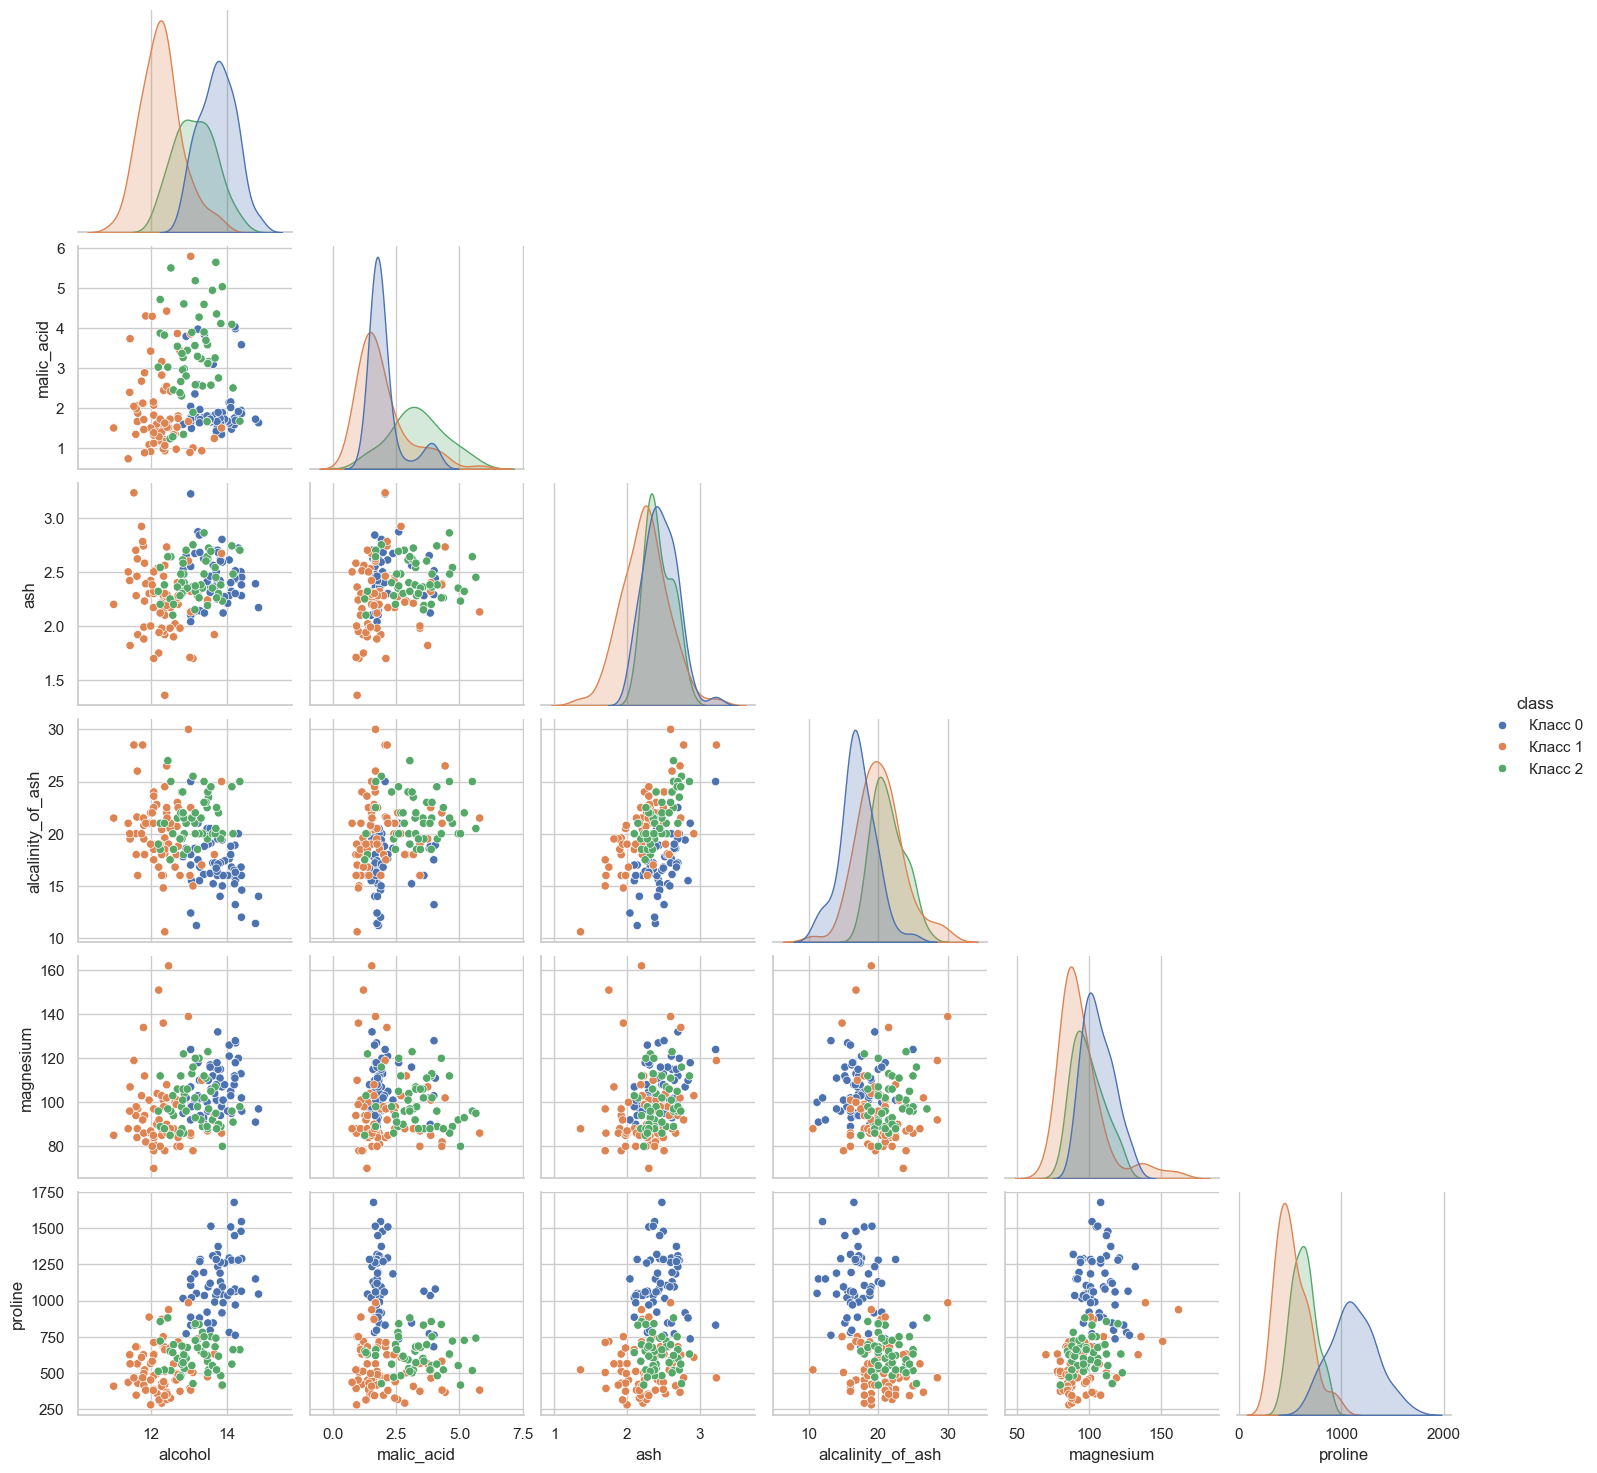

In [37]:
sample_cols = ['alcohol','malic_acid','ash','alcalinity_of_ash','magnesium','proline']
sns.pairplot(df[sample_cols+['class']], hue='class', corner=True)

Text(0.5, 1.0, 'Матрица корреляций')

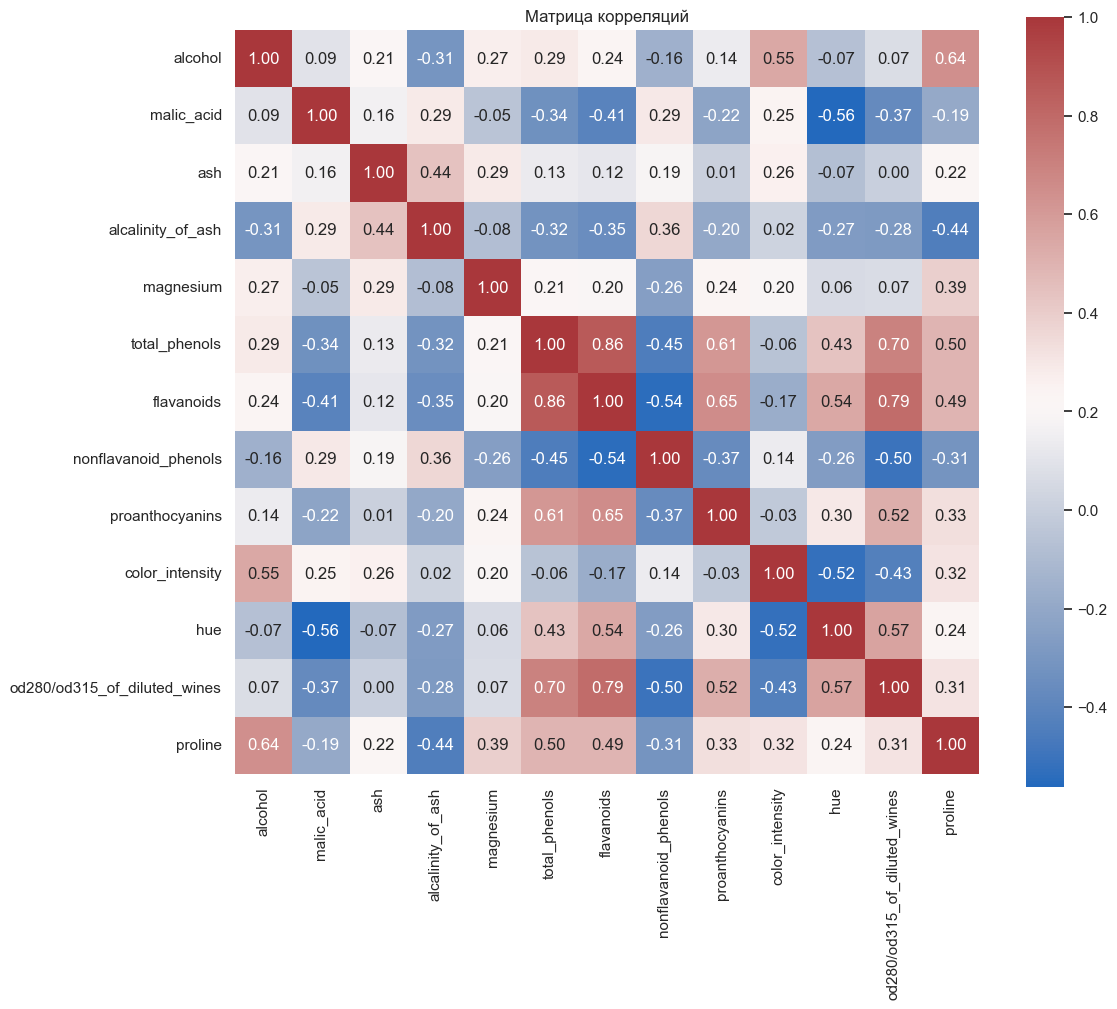

In [54]:
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', square=True)
plt.title("Матрица корреляций")


In [58]:
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.75
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "признак_1", "level_1": "признак_2", 0: "корреляция"})
         .sort_values(by="корреляция", ascending=False)
)

display(high_corr[high_corr["корреляция"] > threshold])


,признак_1,признак_2,корреляция
60,total_phenols,flavanoids,0.864564
75,flavanoids,target,0.847498
103,proline,cluster,0.790042
100,od280/od315_of_diluted_wines,target,0.788230
73,flavanoids,od280/od315_of_diluted_wines,0.787194


Для PCA необходимо удалить высокоскоррелированные данные, а вот для всех остальных методов (Random Forest, t-SNE, umap, KMeans) этого делать не нужно.

Доля объясненной дисперсии: [0.362 0.192 0.111 0.071 0.066 0.049]


Text(0.5, 1.0, 'PCA 2D')

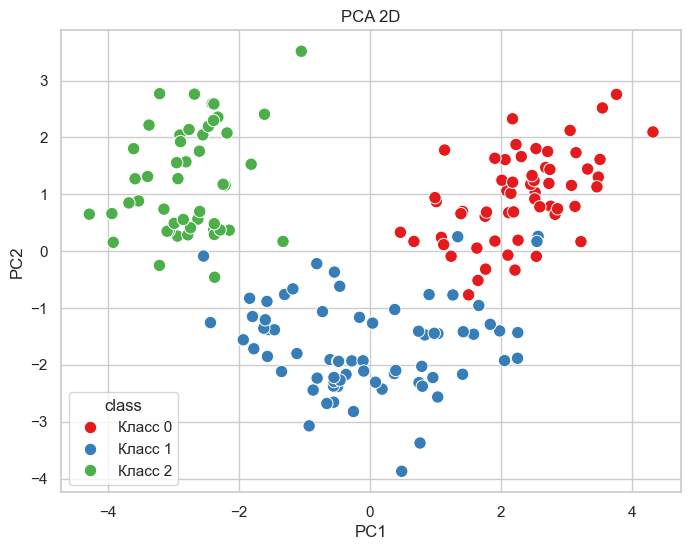

In [53]:
scaler = StandardScaler()
X_s = scaler.fit_transform(df[wine.feature_names])

pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_s)

print("Доля объясненной дисперсии:", np.round(pca.explained_variance_ratio_, 3))

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['class'], s=80, palette='Set1')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA 2D")


**Первая главная компонента (PC1) объясняет 36.2% дисперсии**

Это довольно много, что говорит о том, что существующие признаки имеют общую направленность изменчивости — то есть данные лежат около некоторого главного «направления».
PC1 обычно отражает комбинацию признаков с сильными корреляциями (в Wine dataset — это фенольные характеристики: `flavanoids`, `total_phenols` и др. (см. следующий блок анализа).

**Вторая компонента (PC2) объясняет ещё 19.2% дисперсии**

**PC1 + PC2 = 36% + 19% = 55% всей дисперсии**
Это хороший результат: две компоненты сохраняют более половины всей информации, что позволяет:
- визуализировать классы в 2D-классификации без сильной потери информации
- упростить дальнейший анализ
- уменьшить шум и возможную мультиколлинеарность

**По 2D-графику видно разделение классов**

Это означает, что: дисперсия в данных действительно структурирована по классам PCA может служить хорошим предварительным шагом перед классификацией

**Последующие компоненты дают значительно меньше информации**
0.11, 0.071, 0.066, 0.049 — это постепенно «хвост» дисперсии.

5–6 компонент уже покрывают около 80–85% вариации, но настоящая информативность содержится в первых 2–3 компонентах

Датасет имеет ярко выраженную низкоразмерную структуру, а классы вина различимы уже на первых двух компонентах PCA.
Это говорит о том, что классификация будет работать хорошо, а признаки содержат много линейно объяснимых отличий между типами вина.

Матрица PCA loadings (вклады признаков):


,PC1,PC2,PC3,PC4,PC5,PC6
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144
total_phenols,0.394661,0.065040,0.146179,0.198068,-0.149318,-0.084122
flavanoids,0.422934,-0.003360,0.150682,0.152295,-0.109026,-0.018920
nonflavanoid_phenols,-0.298533,0.028779,0.170368,-0.203301,-0.500703,-0.258594
proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860,-0.533795
color_intensity,-0.088617,0.529996,-0.137306,0.065926,-0.076437,-0.418644


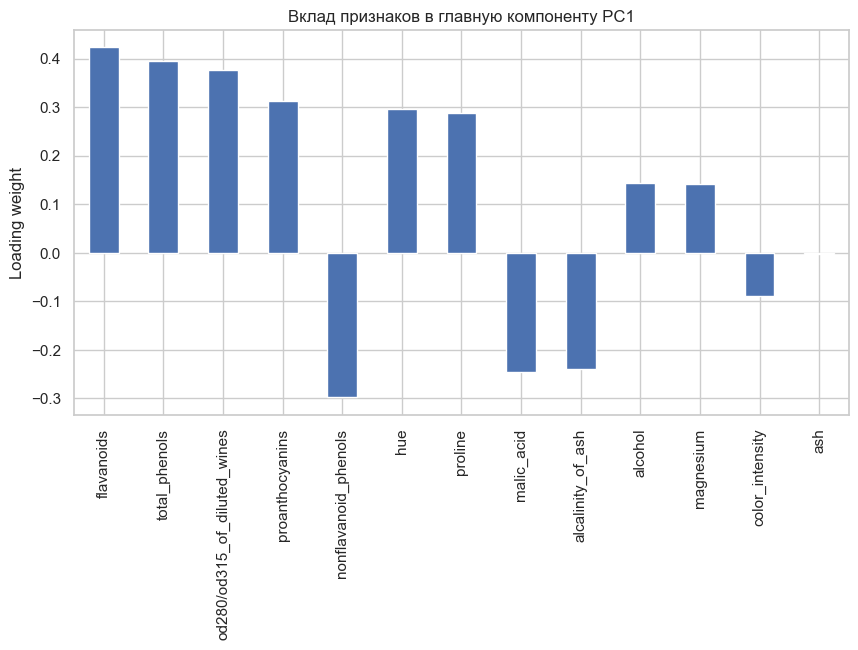

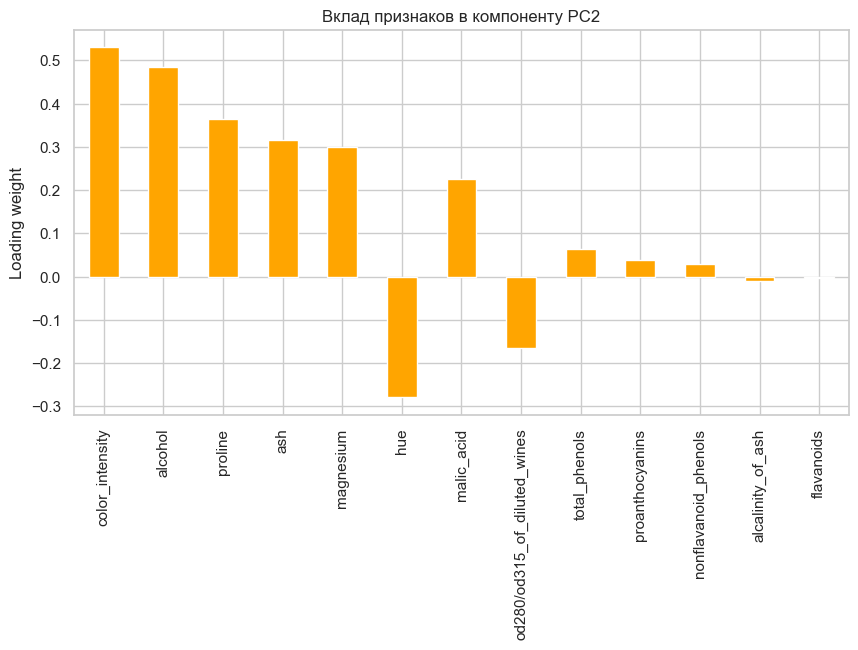

In [60]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=wine.feature_names
)

print("Матрица PCA loadings (вклады признаков):")
display(loadings)

plt.figure(figsize=(10, 5))
loadings["PC1"].sort_values(key=lambda x: abs(x), ascending=False).plot(kind="bar")
plt.title("Вклад признаков в главную компоненту PC1")
plt.ylabel("Loading weight")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
loadings["PC2"].sort_values(key=lambda x: abs(x), ascending=False).plot(kind="bar", color="orange")
plt.title("Вклад признаков в компоненту PC2")
plt.ylabel("Loading weight")
plt.grid(True)
plt.show()



То же самое, но с удалением скоррелированных признаков:

Признаки, которые будут удалены: {'od280/od315_of_diluted_wines', 'cluster', 'flavanoids', 'target'}
Доля объясненной дисперсии: [0.307 0.219 0.123 0.08  0.072 0.054]


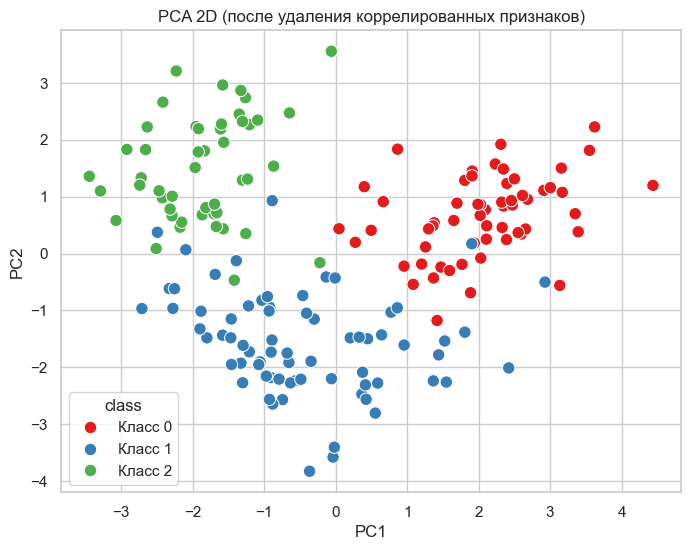

In [85]:
to_drop = set(high_corr[high_corr["корреляция"] > threshold]["признак_2"])
print("Признаки, которые будут удалены:", to_drop)

features_reduced = [f for f in wine.feature_names if f not in to_drop]
X_s_reduced = df[features_reduced]

scaler = StandardScaler()
X_s_scaled = scaler.fit_transform(X_s_reduced)

pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_s_scaled)

print("Доля объясненной дисперсии:", np.round(pca.explained_variance_ratio_, 3))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['class'],
    s=80,
    palette='Set1'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D (после удаления коррелированных признаков)")
plt.show()

Text(0.5, 1.0, 't-SNE 2D')

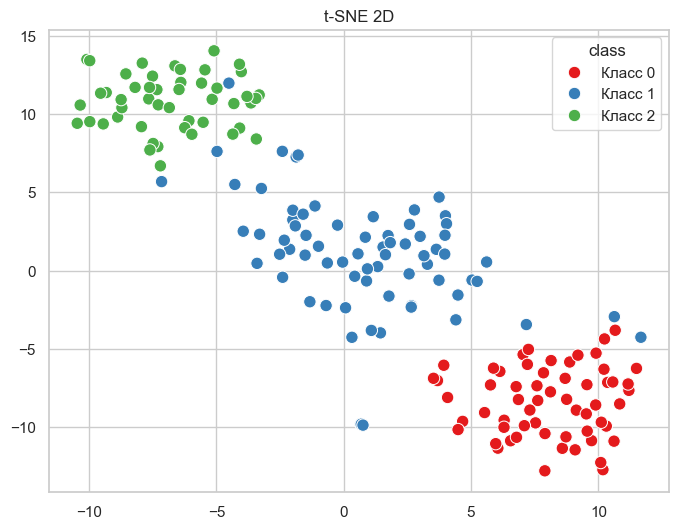

In [40]:
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_s)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['class'], s=80, palette='Set1')
plt.title("t-SNE 2D")


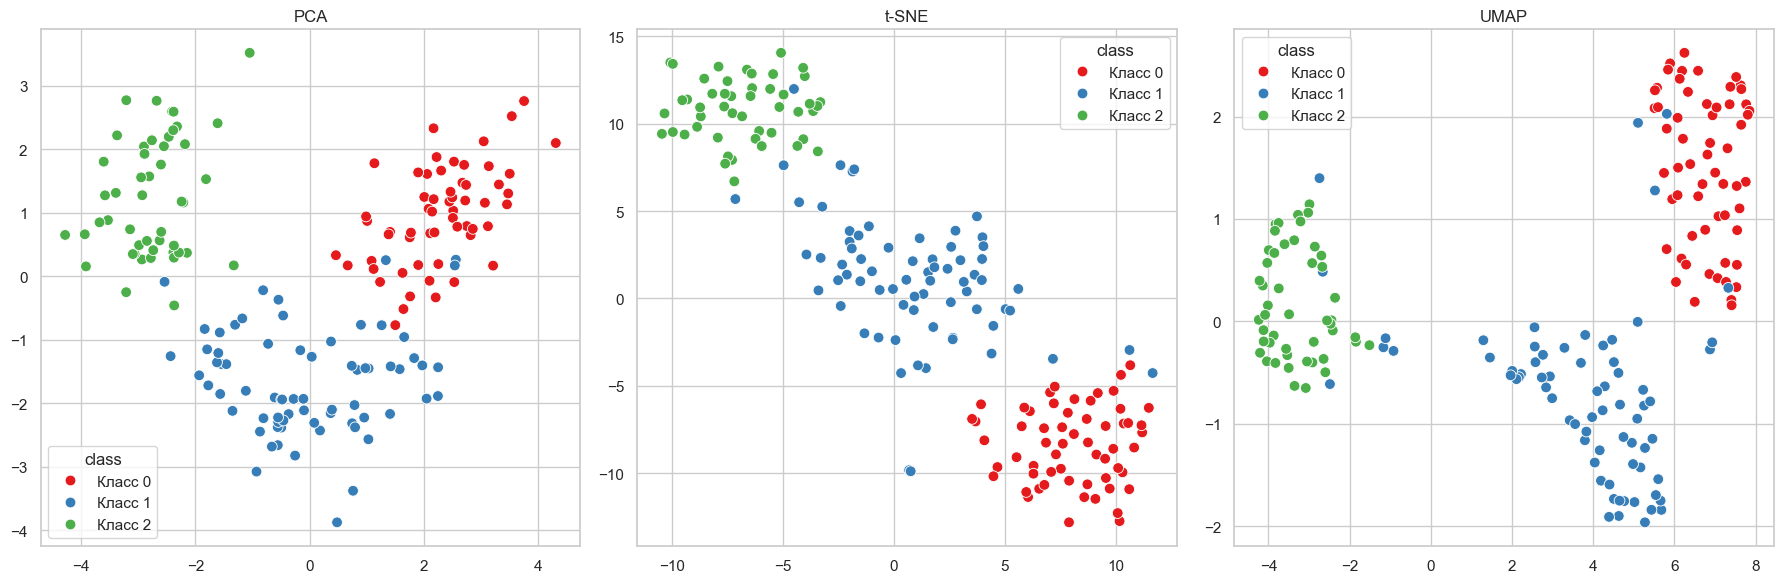

In [81]:
import umap

X_pca_2 = PCA(n_components=2).fit_transform(X_s)

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_s)

tsne = TSNE(n_components=2, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_s)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.scatterplot(x=X_pca_2[:,0], y=X_pca_2[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("PCA")

plt.subplot(1,3,2)
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("t-SNE")

plt.subplot(1,3,3)
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("UMAP")

plt.tight_layout()
plt.show()


t-SNE не даёт линейных коэффициентов признаков (как PCA), но можно оценить корреляцию каждого признака с координатами t-SNE.
Это помогает понять, какие признаки сильнее всего влияют на расположение точек на 2D-графике.

Корреляции признаков с t-SNE компонентами:


,TSNE1,TSNE2
alcohol,0.302602,-0.284612
malic_acid,-0.477742,0.442384
ash,0.036086,-0.010329
alcalinity_of_ash,-0.461918,0.510119
magnesium,0.185625,-0.314649
total_phenols,0.773185,-0.775039
flavanoids,0.859294,-0.895894
nonflavanoid_phenols,-0.487809,0.601818
proanthocyanins,0.484188,-0.644152
color_intensity,-0.266725,0.256513


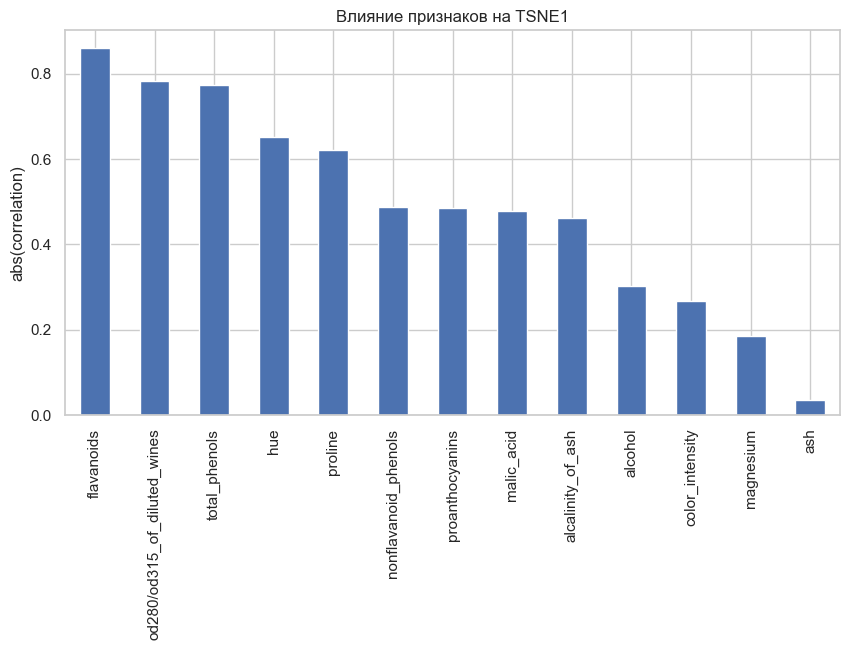

In [70]:
X_tsne_2d = X_tsne
df_features = pd.DataFrame(X_s, columns=wine.feature_names)

correlations = pd.DataFrame({
    "TSNE1": [np.corrcoef(df_features[col], X_tsne_2d[:,0])[0,1] for col in df_features.columns],
    "TSNE2": [np.corrcoef(df_features[col], X_tsne_2d[:,1])[0,1] for col in df_features.columns]
}, index=df_features.columns)

print("Корреляции признаков с t-SNE компонентами:")
display(correlations)

correlations["TSNE1"].abs().sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Влияние признаков на TSNE1")
plt.ylabel("abs(correlation)")
plt.show()


Признаки `flavanoids`, `od280/od315_of_diluted_wines`, `total_phenols` и `hue`имеют наибольшую корреляцию с t-SNE, т.е. они формируют структуру проекции.
Остальные признаки имеют меньшее влияние на расположение точек.

Расширение t-SNE на 3D позволяет визуально анализировать данные в трёхмерном пространстве. Например можно лучше оценить распределение точек и различия между классами, которые не всегда заметны на 2D-графике. Но в случае нашего датасета классы хорошо разделялись и на 2D графике.

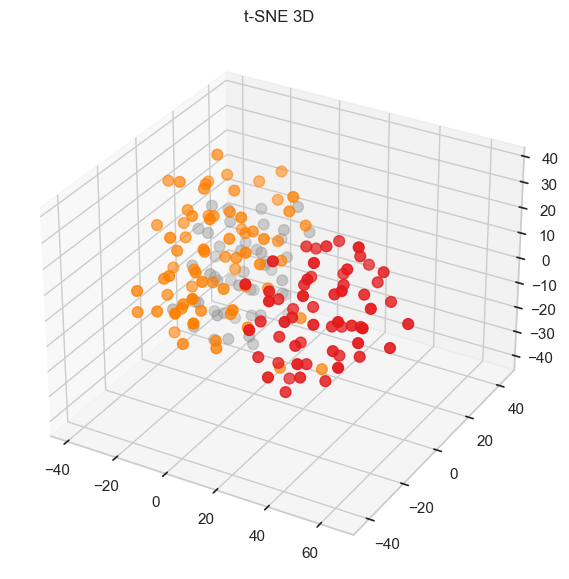

In [64]:
from mpl_toolkits.mplot3d import Axes3D

tsne_3d = TSNE(n_components=3, random_state=42, init='pca')
X_tsne_3d = tsne_3d.fit_transform(X_s)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_tsne_3d[:,0],
    X_tsne_3d[:,1],
    X_tsne_3d[:,2],
    c=df['target'], cmap='Set1', s=60
)

ax.set_title("t-SNE 3D")
plt.show()


`perplexity` — ключевой гиперпараметр t-SNE, который определяет количество ближайших соседей, влияющих на распределение.

Небольшая `perplexity` (5) акцент на очень локальные структуры.

Большая `perplexity` (50) учитываются более глобальные связи.

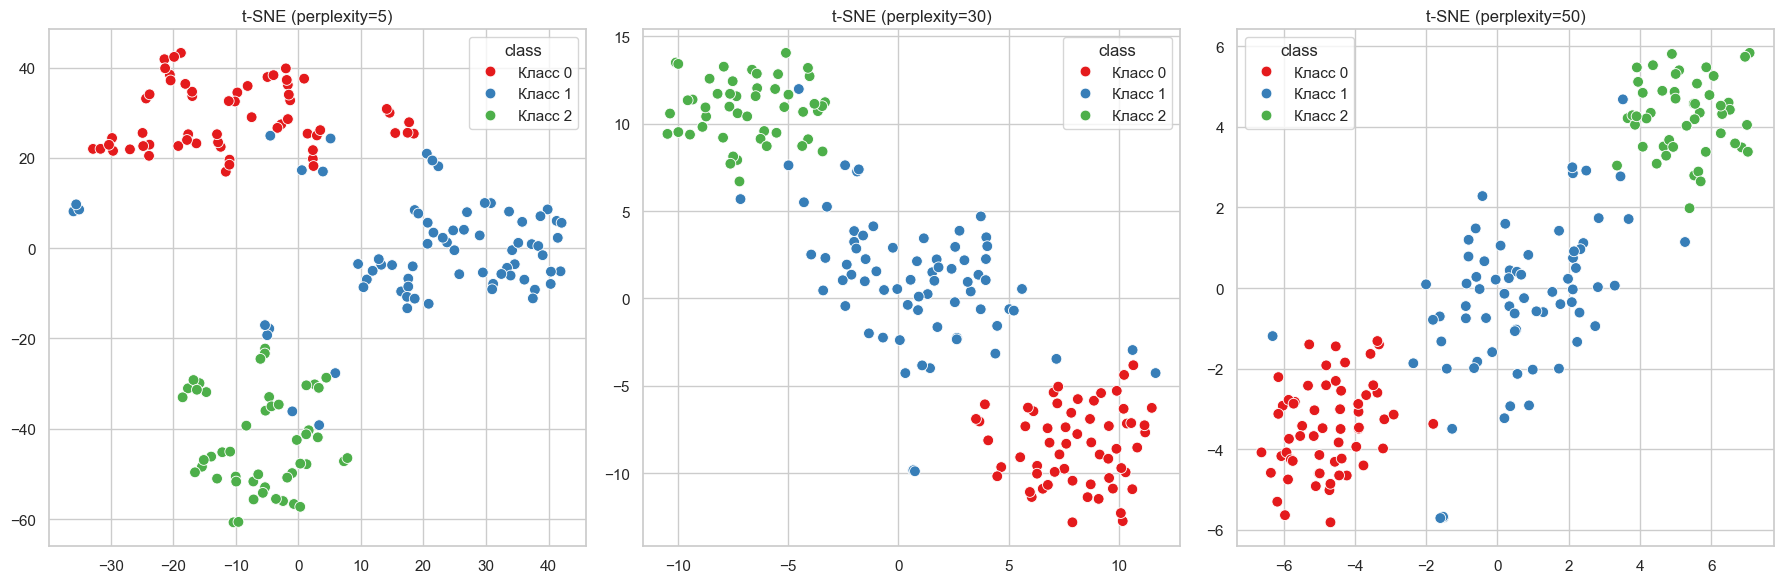

In [65]:
perplexities = [5, 30, 50]

plt.figure(figsize=(18,6))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=p)
    X_tsne_p = tsne.fit_transform(X_s)

    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=X_tsne_p[:,0], y=X_tsne_p[:,1],
                    hue=df["class"], palette="Set1", s=60)
    plt.title(f"t-SNE (perplexity={p})")

plt.tight_layout()
plt.show()


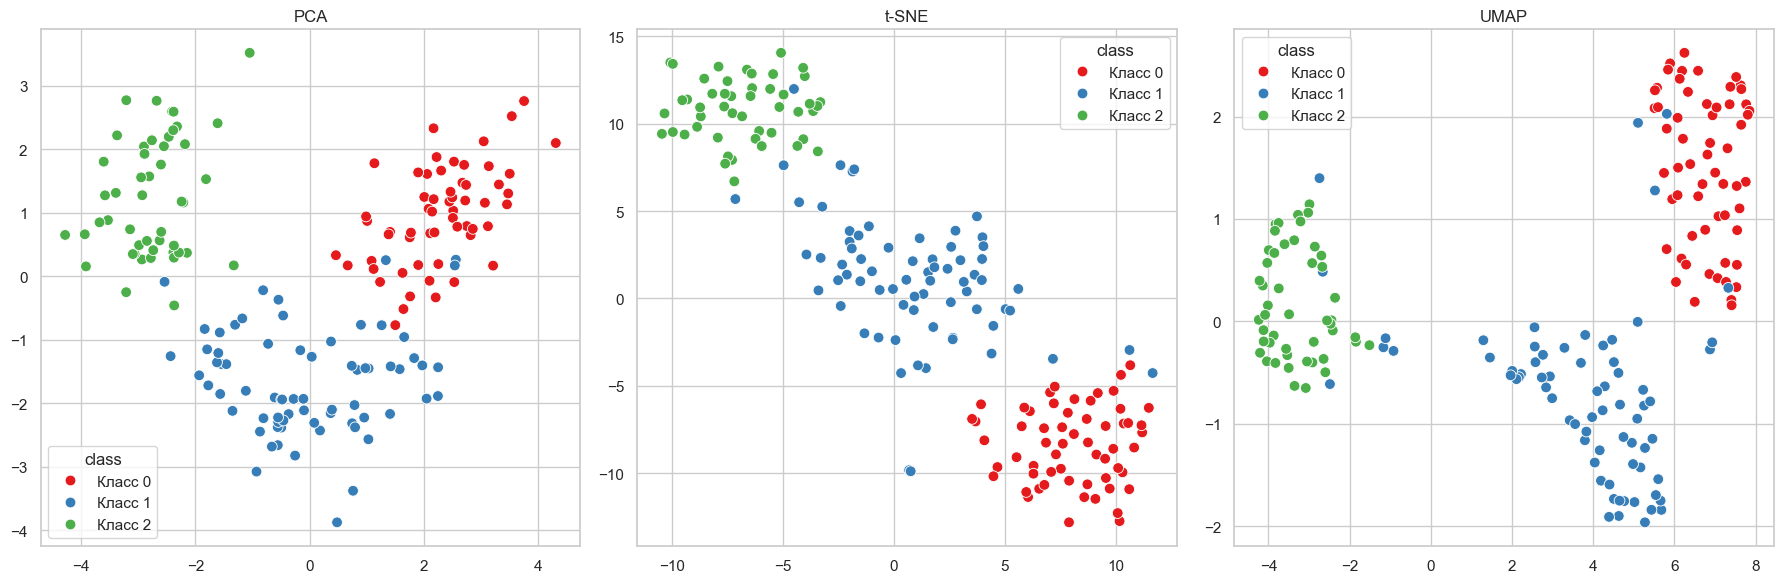

In [83]:
import umap

X_pca_2 = PCA(n_components=2).fit_transform(X_s)

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_s)

tsne = TSNE(n_components=2, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_s)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.scatterplot(x=X_pca_2[:,0], y=X_pca_2[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("PCA")

plt.subplot(1,3,2)
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("t-SNE")

plt.subplot(1,3,3)
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=df['class'], s=60, palette="Set1")
plt.title("UMAP")

plt.tight_layout()
plt.show()


**Random Forest**

Для понимания того, какие признаки наиболее значимы для предсказания целевой переменной, будем использовать метод Random Forest — ансамблевый алгоритм на основе множества решающих деревьев.
Random Forest автоматически оценивает важность каждого признака в процессе обучения. Важность определяется на основе того, насколько сильно каждый признак уменьшает неопределённость (например, Gini impurity) при разбиении деревьев.

Text(0.5, 1.0, 'Важность признаков')

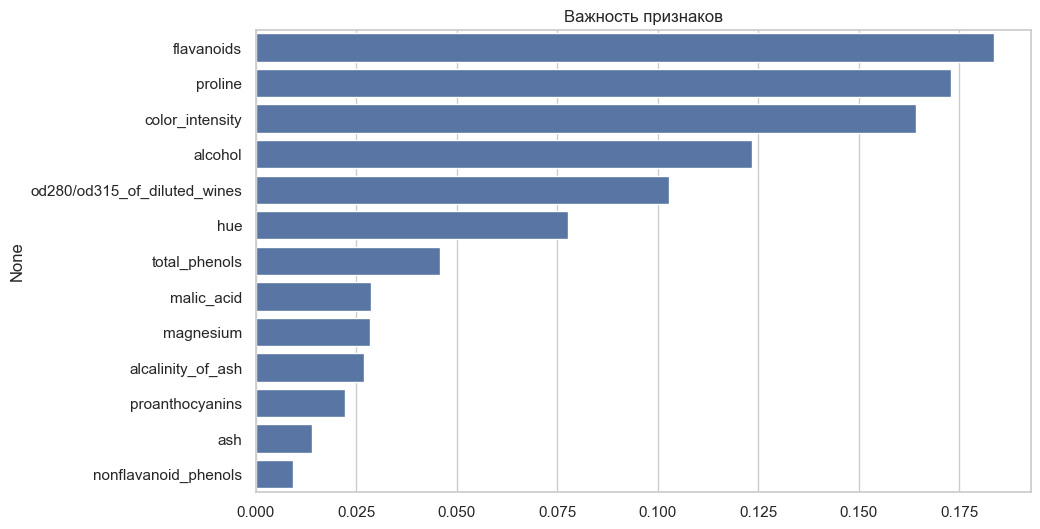

In [74]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_s, df['target'])

importances = pd.Series(rf.feature_importances_, index=wine.feature_names).sort_values(ascending=False)
importances
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Важность признаков")


А это попытка провести подбор оптимальных гиперпараметров на наших данных.

In [75]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                  
    scoring='accuracy',   
    n_jobs=-1,             
    verbose=2
)

grid_search.fit(X_s, df['target'])

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший score:", grid_search.best_score_)


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.5s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_esti

In [76]:
print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


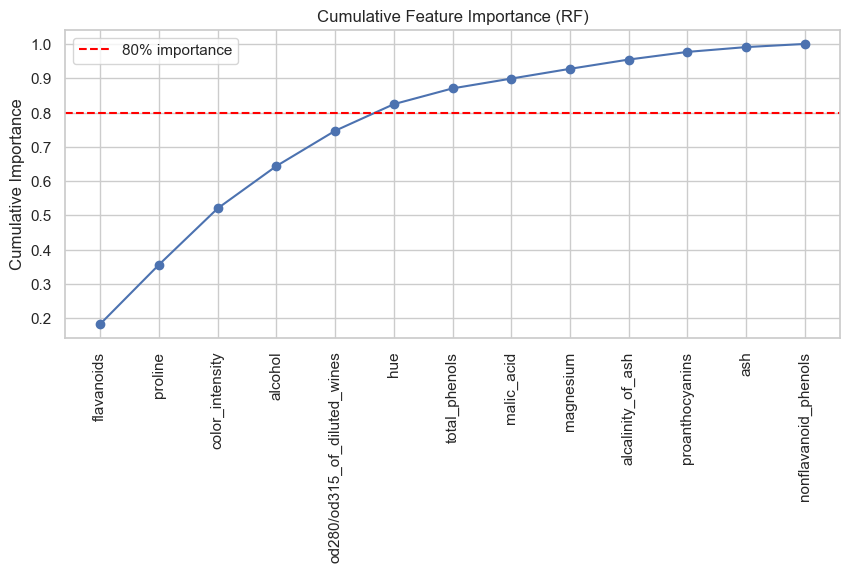


[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=   0.5s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   0.3s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   0.5s
[CV] END bootstrap=False, max_depth=10,

In [77]:
cum_importance = importances.cumsum()
plt.figure(figsize=(10,4))
plt.plot(cum_importance.values, marker='o')
plt.xticks(range(len(importances)), importances.index, rotation=90)
plt.axhline(0.8, color='red', linestyle='--', label='80% importance')
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (RF)")
plt.grid(True)
plt.legend()
plt.show()

Пять признаков дают 80% информации: `flavinoids`, `proline`, `color_intensity`, `alcohol`, `od280/od315_of_diluted_wines`.

**KMeans clustering** — метод разделения набора данных на k кластеров.

Алгоритм инициализирует центры кластеров, присваивает точки ближайшему центру и обновляет центры как средние значений точек. Повторяется до сходимости. 

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_s)

df['cluster'] = clusters
print("Silhouette score:", silhouette_score(X_s, clusters))

pd.crosstab(df['class'], df['cluster'])

Silhouette score: 0.2848589191898987


cluster,0,1,2
class,,,
Класс 0,0,0,59
Класс 1,65,3,3
Класс 2,0,48,0


Для оценки качества кластеризации использовался `Silhouette score`, который показал значение `0.28`, что указывает на слабую, но заметную структуру кластеров. Сравнение с истинными классами через кросстаблицу показывает, что большинство объектов правильно распределились по кластерам.